In [1]:
using PyPlot
using JLD2
using Statistics
using Images, ImageFiltering, Rotations, ImageTransformations, CoordinateTransformations
using ProgressBars

In [ ]:
function mask_ellipse(xc, yc, a, b, θ, width, height)
    """ Mask of size (width, height) of an ellipse rotated by an angle θ, centered on [xc, yc], with HALF major/minor axis a/b"""
    mask = zeros(Integer, (width, height))
    X = range(0, height-1) .- yc
    Y = range(0, width-1) .- xc
    for (i, x) in enumerate(X)
        for (j, y) in enumerate(Y)
            # Rotate back
            x_hor = x*sin(θ) + y*cos(θ)
            y_hor = x*cos(θ) - y*sin(θ)
            
            if (x_hor/a)^2 + (y_hor/b)^2 ≤ 1
                mask[i, j] = 1
            end
        end
    end
    return mask
end

function rotate_img_stripe_angle(img)
    """ Finds the angle at which the stripes are along the horizontal axis,
    ie where a sum along the horizontal axis is maximal """
    θ_range = [0:0.1:π/2;]

    Maximum_hor_mean = zeros(length(θ_range))

    for (i, θ) in enumerate(θ_range)
        imgw = rot_img(img, θ)

        Maximum_hor_mean[i] = maximum(sum(imgw, dims=2))
    end
    return θ_range[argmax(Maximum_hor_mean)]
end

function rot_img(img, θ)
    """ Rotate an image with an angle θ, padd with 0 """
    trfm = recenter(RotMatrix(θ), center(img))
    imgw = parent(warp(img, trfm))
    imgw[isnan.(imgw)] .= 0 # Padd the NaN values to 0
    return imgw
end

function find_rotate_angle_stripes(img)
    """ Find the angle of the stripes and return the image rotated by this angle 
    so that the stripes are along the horizontal axis, and the angle as a 2nd argument """
    θ = rotate_img_stripe_angle(img)
    return rot_img(img, θ), θ
end

find_rotate_angle_stripes (generic function with 1 method)

In [3]:
pathdir = "Y:/StructuralPhaseTransition/2026/02/11/0001" # Stripes 90°
@load "Saved_exp_data/ODs_crop_"*join(split(pathdir, "/")[3:end], "_")*".jld2" ODs_dataset
@load "Saved_exp_data/Stripes_"*join(split(pathdir, "/")[3:end], "_")*".jld2" centers_stripes_ds major_axis_stripes_ds minor_axis_stripes_ds nbr_stripes_ds
Ntot = 185491 # Total atom nbr
factor_ellipse = 2;

Nbr of atoms in this stripe = 2412.251051947962


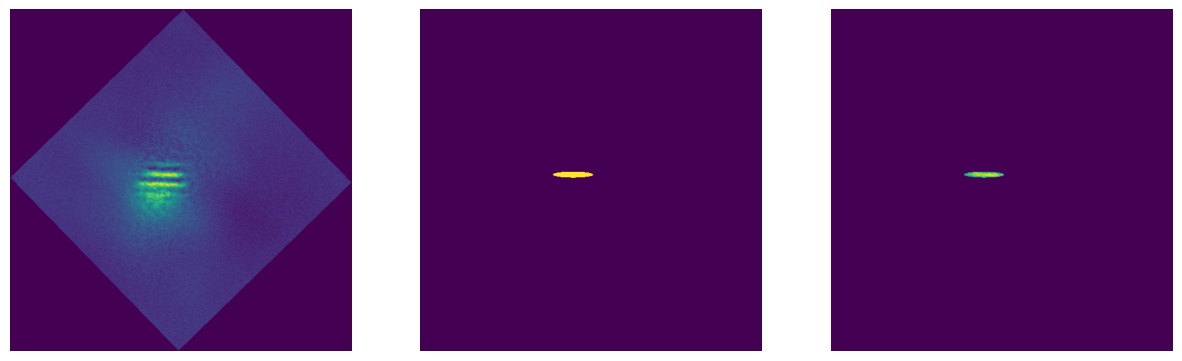

false

In [4]:
i, j, k = 15, 1, 1

close("all")
fig, axes = subplots(1, 3, figsize=(15, 5))

OD = ODs_dataset[i, j, :, :]

OD = Ntot/sum(OD .- minimum(OD)) .* (OD .- minimum(OD)) # Transform the OD in atom/pxl^2

OD_rot = find_rotate_angle_stripes(OD)[1]

axes[1].imshow(OD_rot)
mask = mask_ellipse(centers_stripes_ds[i][j][k][1], centers_stripes_ds[i][j][k][2], major_axis_stripes_ds[i][j][k]/factor_ellipse, minor_axis_stripes_ds[i][j][k]/factor_ellipse, 0, size(OD_rot)[1], size(OD_rot)[2])
axes[2].imshow(mask)
axes[3].imshow(mask .* OD_rot)

println("Nbr of atoms in this stripe = $(sum(mask .* OD_rot))")

for ax in axes
    ax.axis("off")
end

pygui(false)

In [5]:
Nbr_atoms_per_stripe = zeros((size(ODs_dataset)[1:2]..., Int(maximum(nbr_stripes_ds)))) # size = (#Ilaser, #shots, #stripes)

for i in ProgressBar(1:size(ODs_dataset)[1])
    for j in 1:size(ODs_dataset)[2]
        if nbr_stripes_ds[i, j] > 0
            OD = ODs_dataset[i, j, :, :]
            OD = Ntot/sum(OD .- minimum(OD)) .* (OD .- minimum(OD)) # Transform the OD in atom/pxl^2
            OD_rot = find_rotate_angle_stripes(OD)[1]
            for k in 1:Int(nbr_stripes_ds[i, j])
                mask_stripe = mask_ellipse(centers_stripes_ds[i][j][k][1], centers_stripes_ds[i][j][k][2], major_axis_stripes_ds[i][j][k]/factor_ellipse, minor_axis_stripes_ds[i][j][k]/factor_ellipse, 0, size(OD_rot)[1], size(OD_rot)[2])
                Nbr_atoms_per_stripe[i, j, k] += sum(mask_stripe .* OD_rot)
            end
        end
    end
end     

0.0%┣                                              ┫ 0/19 [00:02<00:-32, -2s/it]
10.5%┣█████                                          ┫ 2/19 [00:05<01:19, 5s/it]
15.8%┣███████▍                                       ┫ 3/19 [00:08<01:02, 4s/it]
21.1%┣██████████                                     ┫ 4/19 [00:10<00:51, 3s/it]
26.3%┣████████████▍                                  ┫ 5/19 [00:13<00:45, 3s/it]
31.6%┣██████████████▉                                ┫ 6/19 [00:15<00:38, 3s/it]
36.8%┣█████████████████▎                             ┫ 7/19 [00:17<00:33, 3s/it]
42.1%┣███████████████████▉                           ┫ 8/19 [00:19<00:29, 3s/it]
47.4%┣██████████████████████▎                        ┫ 9/19 [00:21<00:26, 3s/it]
52.6%┣████████████████████████▏                     ┫ 10/19 [00:24<00:24, 3s/it]
57.9%┣██████████████████████████▋                   ┫ 11/19 [00:26<00:21, 3s/it]
63.2%┣█████████████████████████████                 ┫ 12/19 [00:29<00:18, 3s/it]
68.4%┣██████████████████████

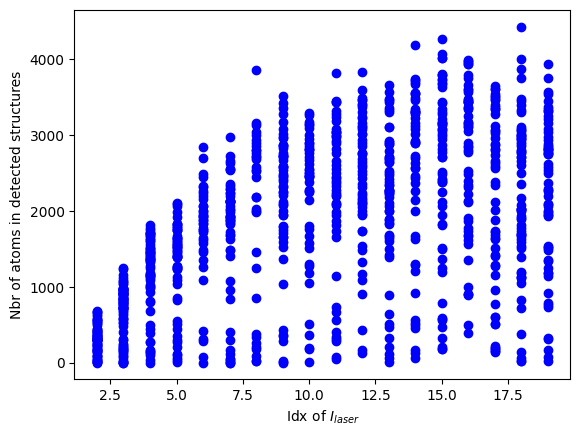

PyObject Text(24.000000000000014, 0.5, 'Nbr of atoms in detected structures')

In [6]:
for i in 1:size(ODs_dataset)[1]
    for j in 1:size(ODs_dataset)[2]
        for k in 1:Int(nbr_stripes_ds[i, j])
            scatter(i, Nbr_atoms_per_stripe[i, j, k], color="b")
        end
    end
end

xlabel(L"Idx of $I_{laser}$")
ylabel("Nbr of atoms in detected structures")

In [7]:
@save "Saved_exp_data/Nbr_atoms_per_stripe_"*join(split(pathdir, "/")[3:end], "_")*".jld2" Nbr_atoms_per_stripe;

In [ ]:
@load "Saved_exp_data/Nbr_atoms_per_stripe_"*join(split(pathdir, "/")[3:end], "_")*".jld2" Nbr_atoms_per_stripe;